В текущем проекте я взяла датасет с платформы Kaggle с данными о клиентах мобильного оператора. В нем представлена информация: о личных данных клиента (есть партнер, иждивенцы, (не)пожилой), о технической возможности подключения к услугам, о подключенных услугах, срок подключения, типа договора/оплаты и отказался или нет клиент от продолжения договора.

Для начала нужно прочитать и посмотреть на данные, затем привести их к удобному для анализа виду.

Далее приступим к поиску закономерностей и причин оттока.

# EDA-анализ на примере датасета Неизвестного Телеком-оператора


## Чтение и преобразование файла

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_defaults()
plt.style.use('default')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
%matplotlib inline

In [2]:
df = pd.read_csv('../datasets/customer_churn.csv', delimiter=',', encoding='utf-8')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# смотрим, какие можно привести к числовому формату или категории

for col in df.columns[1:]:
    if len(df[col].unique()) == 2:
        print(f'{col}:',* df[col].unique())

gender: Female Male
SeniorCitizen: 0 1
Partner: Yes No
Dependents: No Yes
PhoneService: No Yes
PaperlessBilling: Yes No
Churn: No Yes


In [6]:
# приводим к числовому формату, убрав пробелы для точного совпадения
# числовой формат понадобится для построения матрицы корреляций и для облегчения расчетов в будущем
mapping = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].apply(lambda x: x.strip()).map(mapping)

df['TotalCharges'] = df['TotalCharges'].apply(lambda x: x.strip()).apply(lambda x: float(x) if x else 0.0)

In [7]:
# приводим к типу categories, чтобы экономить память
types = {i: 'category' for i in ['gender',
                                 'MultipleLines', 'InternetService',  'Contract', 'PaymentMethod']}
df = df.astype(types)


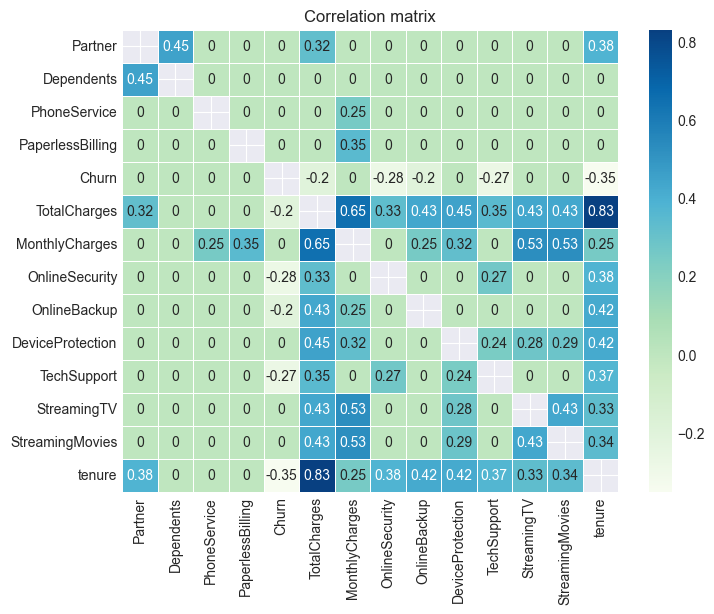

In [8]:
plt.figure(figsize=(8, 6))

# sns.set_style(font_scale=1.4)
df1 = df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'TotalCharges', 'MonthlyCharges', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'tenure']]
mask = np.eye(df1.corr().shape[0], dtype=bool)
# display(mask)
corr_matrix = df1.corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.2] = 0 #убираем слабую корреляцию,чтобы не перегружать график

sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='GnBu', mask=mask)

plt.title('Correlation matrix')
plt.savefig('../visuals/Correlation matrix.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

Положительная корреляция:
 - сильная корреляцию подключенных пакетов услуг и увеличения общей выручки, при этом на месячную оплату влияют не все услуги.
 - наличия партнера и иждивенцев и увеличение общих расходов при наличии партнера. 
 - безбумажные счета и увеличение месячных трат -- автопродление и автооплату сложнее контролировать, поэтому логично увеличение трат.
 - на срок подписки влияет наличие партнера.

Отрицательная корреляция:
 - наличие техподдержки и услуг защиты уменьшает отток. 
 - отток снижается с увеличением срока подписки

In [9]:
df_person = df[['customerID','Partner', 'Dependents', 'gender', 'TotalCharges', 'MonthlyCharges', 'SeniorCitizen', 'tenure', 'Churn']].copy()
mapping = {1:'Yes', 0:'No'}
for col in ['Partner', 'Dependents', 'SeniorCitizen']:
    df_person[col] = df_person[col].map(mapping)
df_person.head()

,customerID,Partner,Dependents,gender,TotalCharges,MonthlyCharges,SeniorCitizen,tenure,Churn
0,7590-VHVEG,Yes,No,Female,29.85,29.85,No,1,0
1,5575-GNVDE,No,No,Male,1889.50,56.95,No,34,0
2,3668-QPYBK,No,No,Male,108.15,53.85,No,2,1
3,7795-CFOCW,No,No,Male,1840.75,42.30,No,45,0
4,9237-HQITU,No,No,Female,151.65,70.70,No,2,1


<Figure size 1200x1000 with 0 Axes>

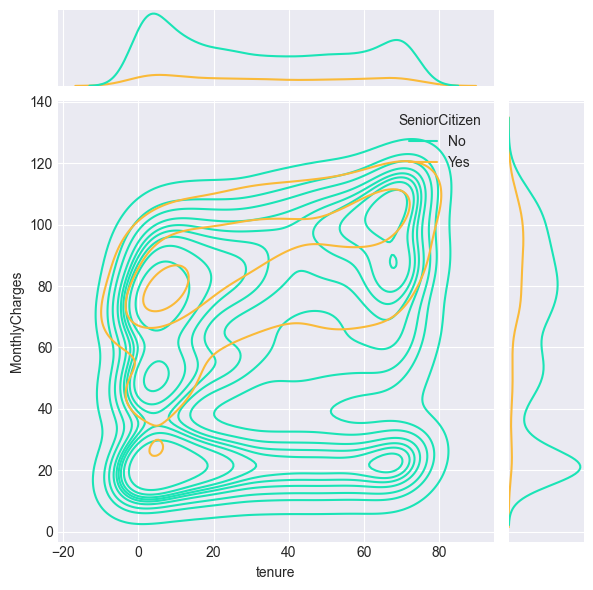

In [10]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='MonthlyCharges', hue='SeniorCitizen', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )
plt.show();

<Figure size 1200x1000 with 0 Axes>

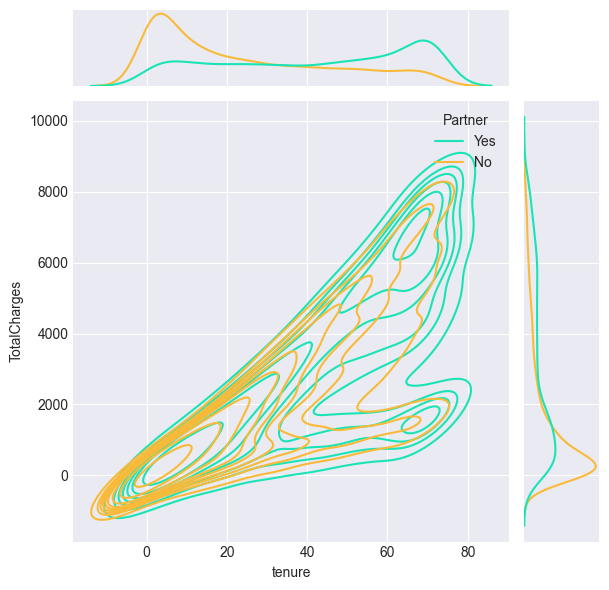

In [11]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='TotalCharges', hue='Partner', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )

plt.show();

<Figure size 1200x1000 with 0 Axes>

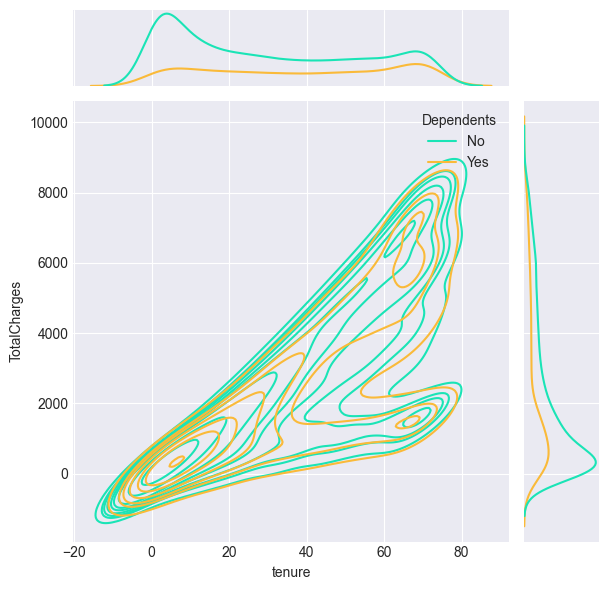

In [12]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='TotalCharges', hue='Dependents', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )

plt.show();

Влияния срока подписки на ежемесячную оплату не наблюдается, однако заметно, что пожилые тратят меньше.

Сравним траты по разным категориям: пол, возраст, семейный статус, наличие иждивенцев.

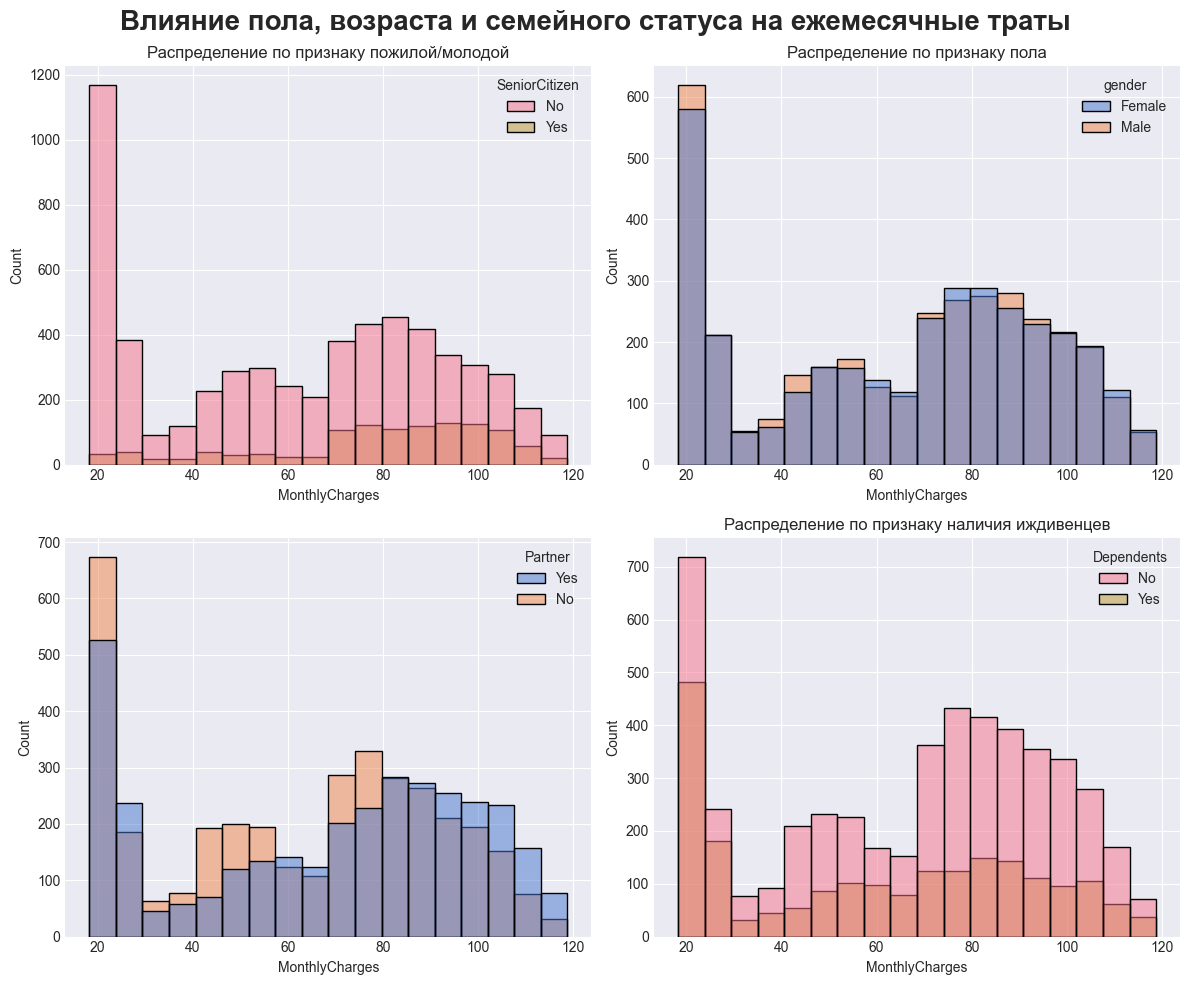

In [13]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,10))
sns.histplot(data=df_person, x='MonthlyCharges', hue='SeniorCitizen', ax=ax1)
plt.suptitle('Влияние пола, возраста и семейного статуса на ежемесячные траты', fontsize=20, fontweight='bold')
ax1.set_title('Распределение по признаку пожилой/молодой')

sns.histplot(data=df_person, x='MonthlyCharges', hue='gender', ax=ax2, palette='muted')
ax2.set_title('Распределение по признаку пола')

sns.histplot(data=df_person, x='MonthlyCharges', hue='Partner', ax=ax3, palette='muted')
ax4.set_title('Распределение по признаку наличия партнера')

sns.histplot(data=df_person, x='MonthlyCharges', hue='Dependents', ax=ax4)
ax4.set_title('Распределение по признаку наличия иждивенцев')

plt.tight_layout()
plt.savefig('../visuals/Correlation monthly.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

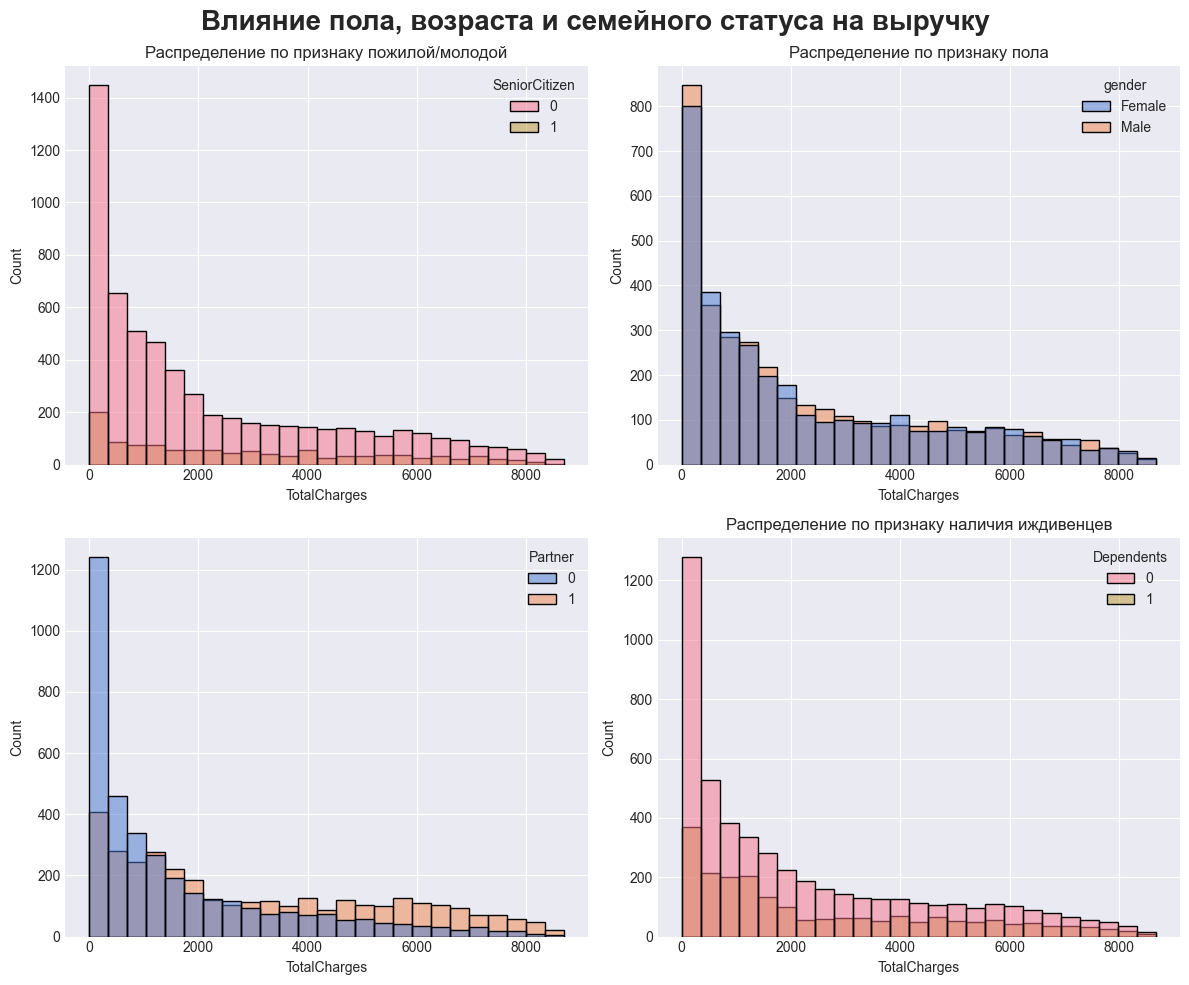

In [14]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,10))
sns.histplot(data=df, x='TotalCharges', hue='SeniorCitizen', ax=ax1)
plt.suptitle('Влияние пола, возраста и семейного статуса на выручку', fontsize=20, fontweight='bold')
ax1.set_title('Распределение по признаку пожилой/молодой')

sns.histplot(data=df, x='TotalCharges', hue='gender', ax=ax2, palette='muted')
ax2.set_title('Распределение по признаку пола')

sns.histplot(data=df, x='TotalCharges', hue='Partner', ax=ax3, palette='muted')
ax4.set_title('Распределение по признаку наличия партнера')

sns.histplot(data=df, x='TotalCharges', hue='Dependents', ax=ax4)
ax4.set_title('Распределение по признаку наличия иждивенцев')

plt.tight_layout()
plt.savefig('../visuals/Correlation total.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [15]:
family = pd.crosstab(index=df['Dependents'], columns=df_person['Partner'], values=df_person['MonthlyCharges'], aggfunc='median')
display(family)

Partner,No,Yes
Dependents,,
0,69.7,81.4
1,50.1,65.0


Наличие партнера увеличивает траты, даже не смотря на то, что наличие иждивенцев их уменьшает

In [16]:
payment = pd.crosstab(
    df['Contract'], df['PaymentMethod'],
    values=df['Churn'],
    aggfunc='sum', normalize=True
)*100
print('% Оттока в разрезе формы оплаты и срока договора')
display(payment.round(1))

% Оттока в разрезе формы оплаты и срока договора


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,10.8,9.5,53.2,15.1
One year,2.0,2.2,3.4,1.2
Two year,1.0,0.7,0.7,0.2


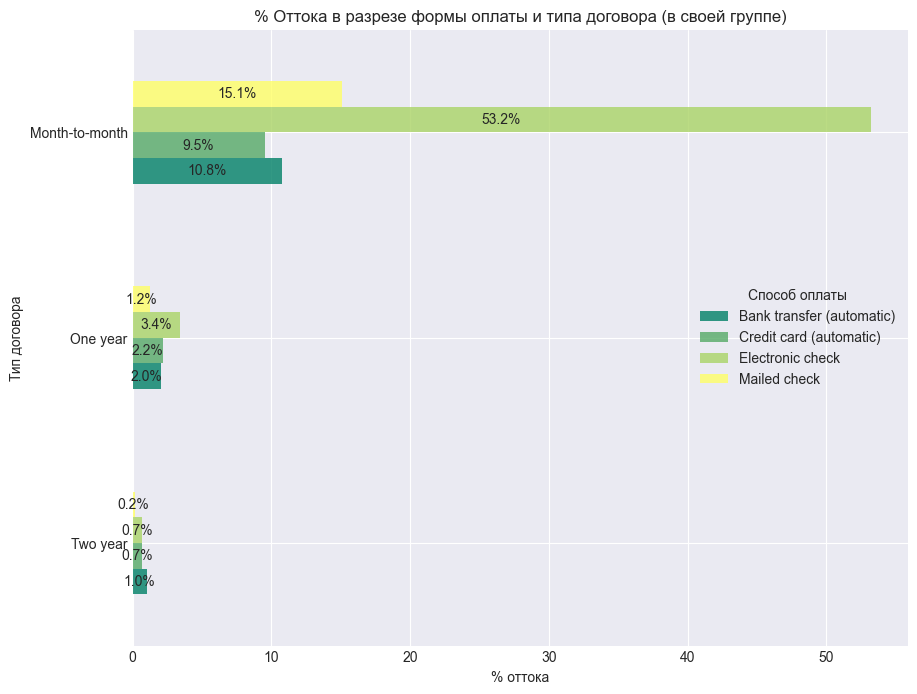

In [17]:
order = ['Two year', 'One year', 'Month-to-month']

ax = payment.reindex(order).plot(kind='barh',
                  ylabel='Тип договора', xlabel='% оттока',
                  figsize=(10,8), alpha=0.8, colormap='summer', rot=0)

ax.legend(loc='center right', title='Способ оплаты')
plt.title('% Оттока в разрезе формы оплаты и типа договора (в своей группе)')
# Добавление подписей внутри/над столбцами
for p in ax.containers:
    ax.bar_label(p, label_type='center', fmt='%1.1f%%') # 'edge' - над, 'center' - внутри
plt.savefig('../visuals/Contract type Churn.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

## Поиск закономерностей в связке подключенных услуг, возраста, оттока

Чтобы не перегружать график за счет поля 'no internet service', показатель которого везде одинаков, нужно исключить эти данные из анализа.

Для начала проверим, правильно ли у нас указаны данные и 'no internet service' стоит одинаково во всех колонках с услугами и согласуется с информацией об интернет-сетях

In [18]:
service_check = df[['InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies']].copy()
total = 0
for service in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']:

    # Находим строки, где InternetService='No' но услуга не 'No internet service'
    mask = (service_check['InternetService'] == 0) & \
           (service_check[service] != 'No internet service')
    no_service = mask.sum()
    if no_service > 0:
        print(f"в сервисе {service} найдено {no_service} несоответствий")
    total += no_service
print(f"всего найдено {total} несоответствий")

всего найдено 0 несоответствий


Проверка показала, что если указано, что интернета нет, то и в остальных колонках по доп услугам это проставлено аналогично и корректно. Теперь можно в анализе оттока по доп услугам считать только тех людей, у кого есть интернет.
Сделаем визуализацию, чтобы понять, у какой услуги наибольшая разница в оттоке между подключившими и не подключившими услугу

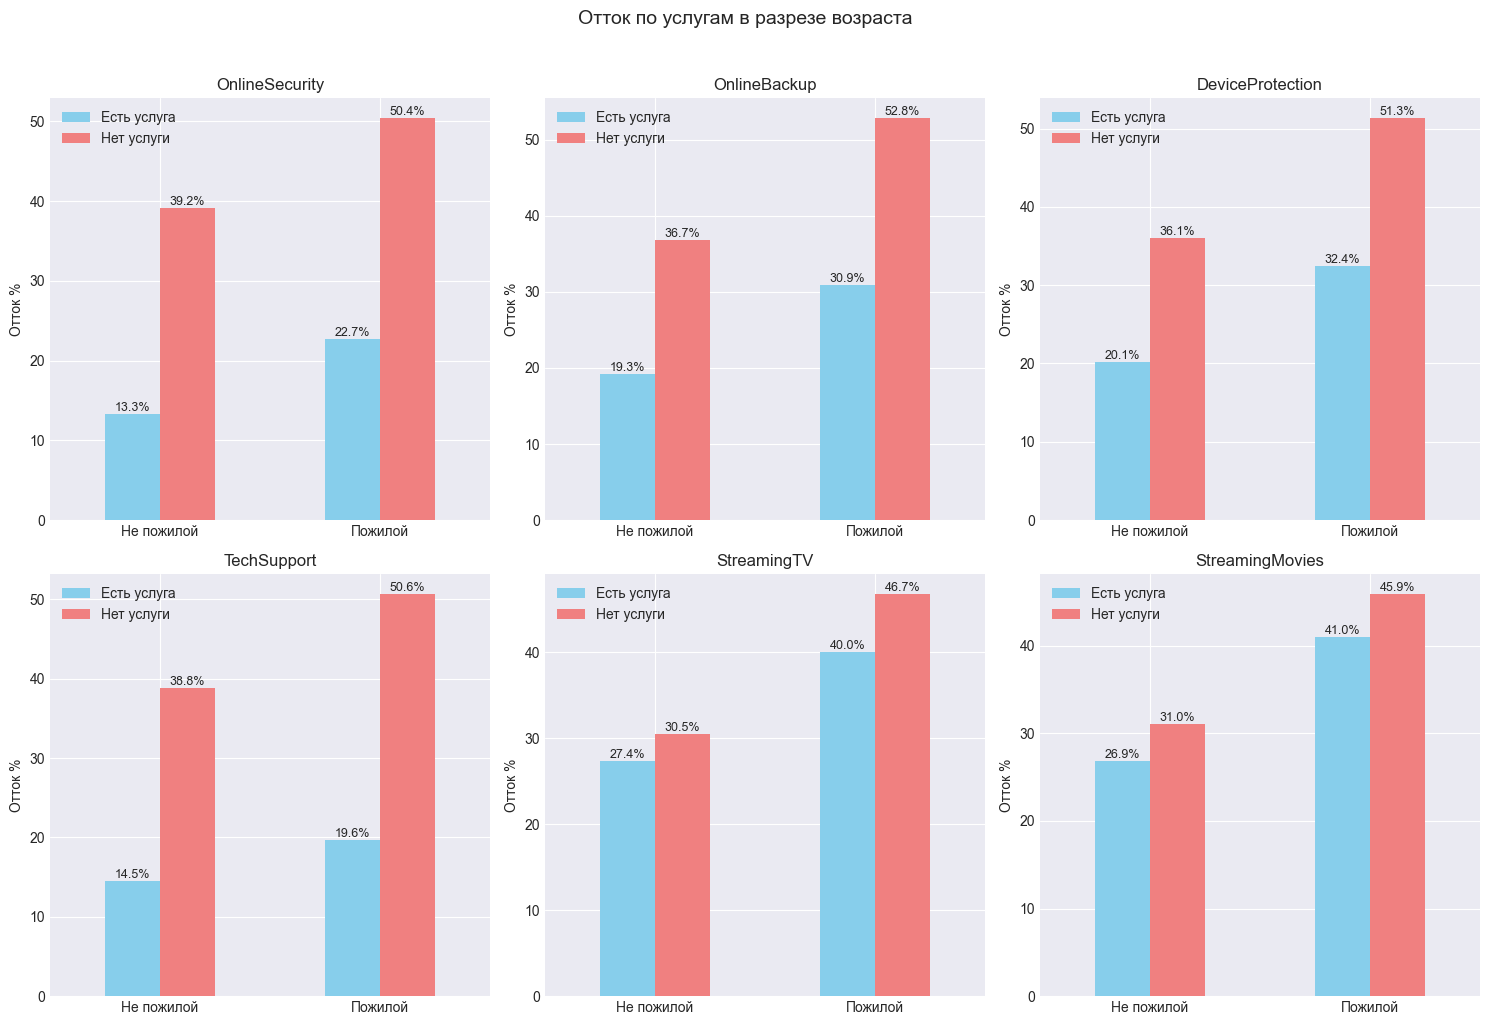

In [19]:
# для визуализации оставаляем только тех, у кого есть интернет
customers_with_internet = df[df['InternetService'] != 0].copy()
mapping = {1.0: 'Yes', 0.0: 'No'}

services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in services:
    customers_with_internet[col] = customers_with_internet[col].map(mapping)

# Подготовка данных для графика
plot_data = []
for service in services:
    for age in [0, 1]:
        for status in ['Yes', 'No']:
            mask = (customers_with_internet['SeniorCitizen'] == age) & \
                   (customers_with_internet[service] == status)
            churn_rate = customers_with_internet.loc[mask, 'Churn'].mean() * 100
            count = mask.sum()

            plot_data.append({
                'Услуга': service,
                'Возраст': 'Пожилой' if age else 'Не пожилой',
                'Статус': 'Есть услуга' if status == 'Yes' else 'Нет услуги',
                'Отток %': churn_rate,
                'Клиентов': count
            })

plot_df = pd.DataFrame(plot_data)

# Создаем графики
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, service in enumerate(services):
    ax = axes[idx]
    data = plot_df[plot_df['Услуга'] == service]

    # Группированная столбчатая диаграмма
    pivot_data = data.pivot(index='Возраст', columns='Статус', values='Отток %')
    pivot_data.plot(kind='bar', ax=ax, color=['skyblue','lightcoral'])

    ax.set_title(service, fontsize=12)
    ax.set_ylabel('Отток %')
    ax.set_xlabel('')
    ax.legend(title='')
    ax.tick_params(axis='x', rotation=0)

    # Добавляем значения на столбцы
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.suptitle('Отток по услугам в разрезе возраста', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../visuals/Отток по услугам в разрезе возраста.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

Для пожилых особенно важна тех.поддержка и безопасность -- подключение этих услуг существенно снижает процент оттока, а вот стриминговые фильмы и тв не являются для пользователей чем-то особенным, скорее всего конкуренты могут предложить аналогичные условия.


## Сравнение динамики поведения пользователей по возрасту

In [20]:
# Есть ли у пожилых партнеры/иждивенцы
family_senior = df_person.pivot_table(
    values='Churn',
    columns='SeniorCitizen',
     index='Partner',
     aggfunc='mean',
     fill_value=0
)*100
print("Отток пожилых в зависимости от наличия партнера (%):")
print(family_senior.round(1))

# Проверяем иждивенцев
dependents_senior = df_person.pivot_table(
    values='Churn',
    columns='SeniorCitizen',
     index='Dependents',
     aggfunc='mean',
     fill_value=0
)*100
print("\nОтток пожилых в зависимости от наличия иждивенцев (%):")
print(dependents_senior.round())

Отток пожилых в зависимости от наличия партнера (%):
SeniorCitizen    No   Yes
Partner                  
No             30.0  48.9
Yes            16.6  34.6

Отток пожилых в зависимости от наличия иждивенцев (%):
SeniorCitizen    No   Yes
Dependents               
No             28.0  43.0
Yes            15.0  24.0


Наличие партнера и/или иждивенца существенно снижает вероятность отписки для обеих категорий - пожилых и непожилых.

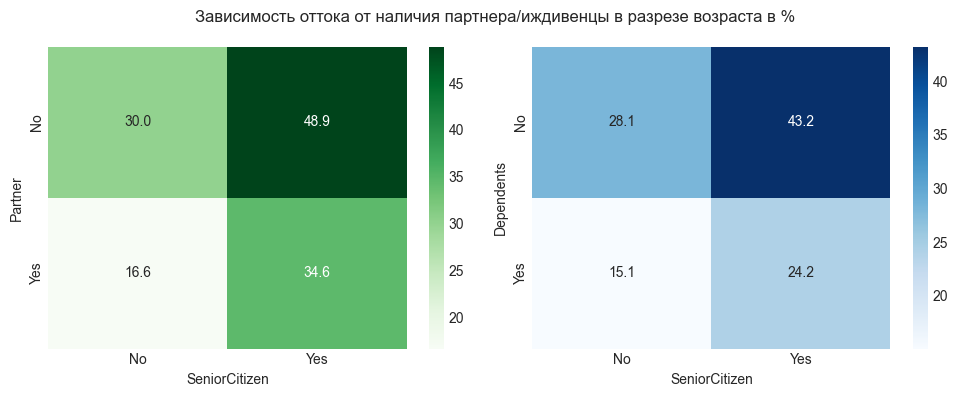

In [21]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
fig.suptitle('Зависимость оттока от наличия партнера/иждивенцы в разрезе возраста в %')

sns.heatmap(family_senior, ax=ax1, fmt='.1f', annot=True, cmap='Greens')

sns.heatmap(dependents_senior, ax=ax2, fmt='.1f', annot=True, cmap='Blues')

plt.tight_layout()
plt.savefig('../visuals/Personal_Churn.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

# Выводы анализа:
- Наличие партнера и/или иждивенца существенно снижает вероятность отписки для обеих категорий - пожилых и непожилых.
- Больше всего отписок в первые полгода-год
- Для пожилых особенно важна тех.поддержка и безопасность -- подключение этих услуг существенно снижает процент оттока, а вот стриминговые фильмы и тв не являются для пользователей чем-то особенным, скорее всего конкуренты могут предложить аналогичные условия.
- Самый большой отток среди пользователей с ежемесячной оплатой и оплатой чеками (почтовыми или онлайн-счетами). Таким пользователям легче мониторить свои подписки и отменять их
- Непожилые тратят больше пожилых
- Наличие партнера увеличивает траты, даже не смотря на то, что наличие иждивенцев их уменьшает